# Import Modules

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import glob
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor

os.makedirs("models", exist_ok=True)
os.makedirs("features", exist_ok=True)
os.makedirs("splits", exist_ok=True)


# Data Loading and Hybrid Feature Extraction

In [3]:
def extract_hybrid_features(file_path, max_pad_len=128):
    try:
        # Load audio with NO offset to avoid skipping short clips
        y, sr = librosa.load(file_path, duration=3)

        # Pad short audio to at least 0.5 seconds
        # This ensures we always have enough frames for Delta/Delta-Delta
        min_samples = int(sr * 0.5) 
        if len(y) < min_samples:
            y = np.pad(y, (0, min_samples - len(y)), mode='constant')
        
        # Normalize audio
        y = librosa.util.normalize(y)
    
        # 1. MFCC - 20
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    
        # Delta MFCC - 20
        mfcc_delta = librosa.feature.delta(mfcc)
    
        # Delta-Delta MFCC - 20
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
    
        # 2. Chroma - 12
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    
        # 3. RMS Energy - 1
        rms = librosa.feature.rms(y=y)
    
        # 4. Spectral Features - 3
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    
        # 5. Zero Crossing Rate - 1
        zcr = librosa.feature.zero_crossing_rate(y)
    
        # Combine All Features - 77
        combined = np.vstack([
            mfcc,
            mfcc_delta,
            mfcc_delta2,
            chroma,
            rms,
            centroid,
            bandwidth,
            rolloff,
            zcr
        ])

        # Padding / Truncation
        if combined.shape[1] < max_pad_len:
            pad_width = max_pad_len - combined.shape[1]
            combined = np.pad(combined, ((0,0),(0,pad_width)), mode='constant')
        else:
            combined = combined[:, :max_pad_len]
    
        return combined.T
        
    except Exception as e:
        print(f"Error for {file_path}: {type(e).__name__} - {e}")
        return None


def makeThePlot(Y):
    df = pd.DataFrame({'emotion': Y})
    
    # Set the visual style
    plt.figure(figsize=(10, 5))
    sns.set_style("whitegrid")
    
    # Create the distribution chart
    ax = sns.countplot(x='emotion', data=df, palette='viridis', order=df['emotion'].value_counts().index)
    
    # Add titles and labels
    plt.title('Distribution of Emotions in Dataset', fontsize=15)
    plt.xlabel('Emotion Category', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45) # Rotates labels for better readability
    
    # Show the plot
    plt.show()

Extracting hybrid features from 7442 CREMA-D files...


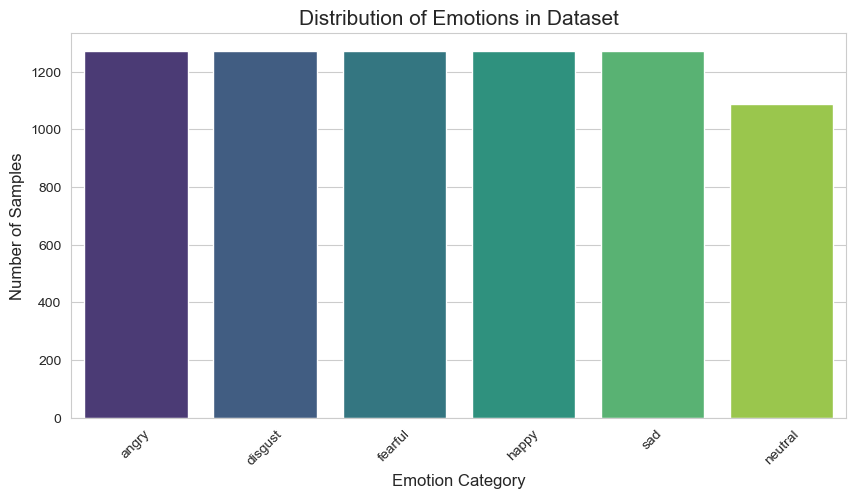

In [5]:
# CREMA-D emotion mapping
CREMAD_MAP = {'ANG':'angry', 'DIS':'disgust', 'FEA':'fearful', 'HAP':'happy', 
              'NEU':'neutral', 'SAD':'sad'}
def load_cremad_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} CREMA-D files...")

    for file in file_list:
        # Filename example: 1001_DFA_ANG_XX.wav
        # Split by '_' and take the 3rd element (index 2)
        code = os.path.basename(file).split('_')[2]
        emotion = CREMAD_MAP.get(code)
        if emotion:
            X.append(extract_hybrid_features(file))
            y.append(emotion)
            
    return np.array(X), np.array(y)

CREMAD_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\CREMA-D\AudioWAV"
X_cremad, y_cremad = load_cremad_data(CREMAD_PATH)


# 6 emotions : angry, fearful, disgust, sad, happy, neutral
makeThePlot(y_cremad)

Extracting hybrid features from 535 EMO-DB files...


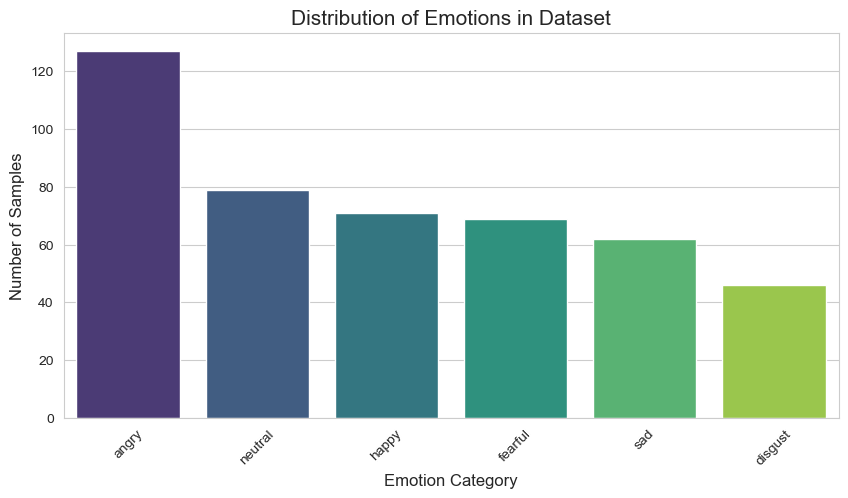

In [6]:
# EMO-DB emotion mapping
# W:Wut (angry), L:Langeweile (boredom), E:Ekel (disgust), A:Angst (fearful), 
# F:Freude (happy), T:Trauer (sad), N:Neutral (neutral)
EMODB_MAP = {'W':'angry', 'L':'boredom', 'E':'disgust', 'A':'fearful', 
             'F':'happy', 'T':'sad', 'N':'neutral'}

def load_emodb_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} EMO-DB files...")

    for file in file_list:
        fname = os.path.basename(file)
        # The 6th character (index 5) represents the emotion
        code = fname[5]
        emotion = EMODB_MAP.get(code)
        if emotion == 'boredom': # skipping the feature with least counts
            continue
        if emotion:
            X.append(extract_hybrid_features(file))
            y.append(emotion)
            
    return np.array(X), np.array(y)

EMODB_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\EMO-DB\wav"
X_emodb, y_emodb = load_emodb_data(EMODB_PATH)


# 7 emotions : angry, boredom, disgust, fearful, happy, sad, neutral
makeThePlot(y_emodb)

Extracting hybrid features from 35000 ESD files...


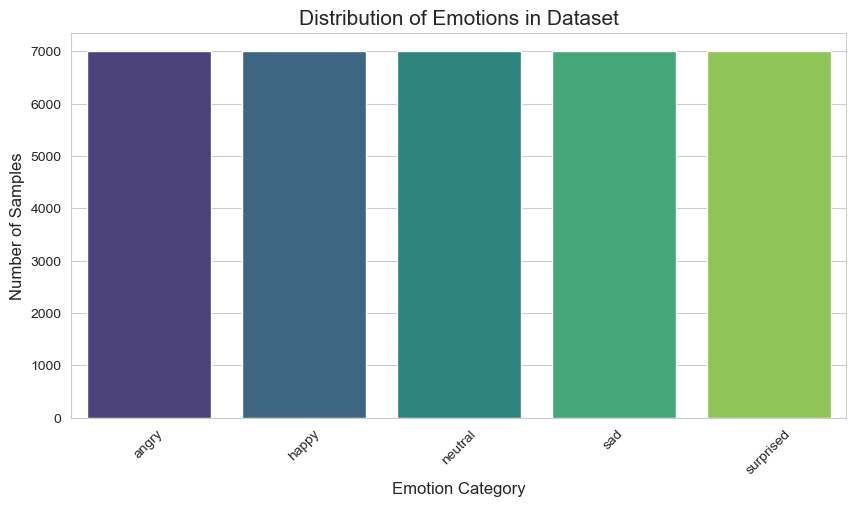

In [7]:
# ESD emotion mapping
# ESD has folders: 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise'
ESD_MAP = {
    'angry': 'angry', 
    'happy': 'happy', 
    'neutral': 'neutral', 
    'sad': 'sad', 
    'surprise': 'surprised'
}

def load_esd_data(data_path):
    X, y = [], []
    # This glob pattern goes into: Speaker Folders (0001) -> Emotion Folders (Angry) -> .wav
    file_list = glob.glob(os.path.join(data_path, "*", "*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} ESD files...")

    for file in file_list:
        folder_name = os.path.basename(os.path.dirname(file)).lower()
        emotion = ESD_MAP.get(folder_name)
        if emotion:
            X.append(extract_hybrid_features(file))
            y.append(emotion)
            
    return np.array(X), np.array(y)

ESD_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\ESD\Emotion Speech Dataset"
X_esd, y_esd = load_esd_data(ESD_PATH)


# 5 emotions : angry, surprised, happy, sad, neutral

makeThePlot(y_esd)

Extracting hybrid features from 3200 HINDI files...


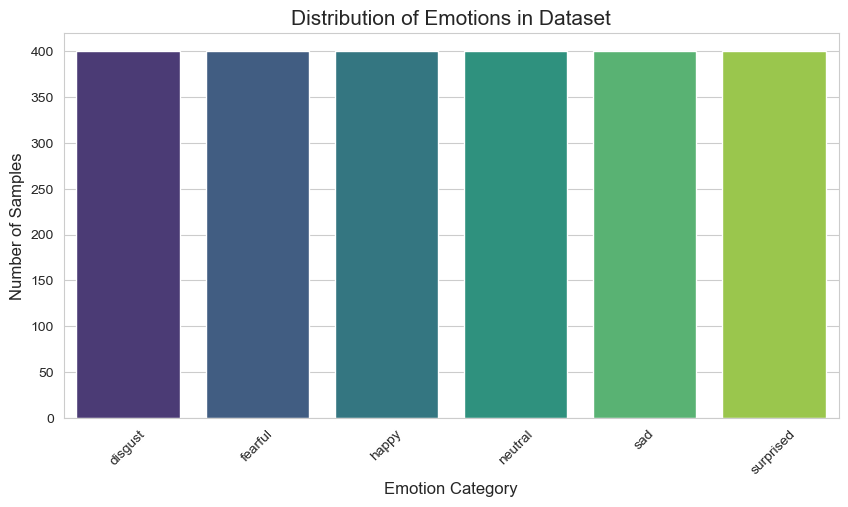

In [ ]:
# Mapping to your standard labels
HINDI_MAP = {
    'neutral': 'neutral',
    'happy': 'happy',
    'sad': 'sad',
    'angry': 'angry',
    'fear': 'fearful',
    'disgust': 'disgust',
    'surprise': 'surprised',
    'sarcastic': 'sarcastic'
}

def load_hindi_data(data_path):
    X, y = [], []
    # This pattern goes into: Speaker (6) -> Session (session1) -> Emotion (neutral) -> *.wav
    file_list = glob.glob(os.path.join(data_path, "*", "*", "*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} HINDI files...")

    for file in file_list:
        folder_name = os.path.basename(os.path.dirname(file)).lower()
        emotion = HINDI_MAP.get(folder_name)
        if emotion == 'sarcastic': # skipping the feature with least counts
            continue
        if emotion:
            X.append(extract_hybrid_features(file))
            y.append(emotion)
            
    return np.array(X), np.array(y)

HINDI_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\HINDI\my Dataset"
X_hindi, y_hindi = load_hindi_data(HINDI_PATH)


# 8 emotions : angry, surprised, sarcastic, disgust, fearful, happy, sad, neutral

makeThePlot(y_hindi)

Extracting hybrid features from 2400 JL Corpus files...


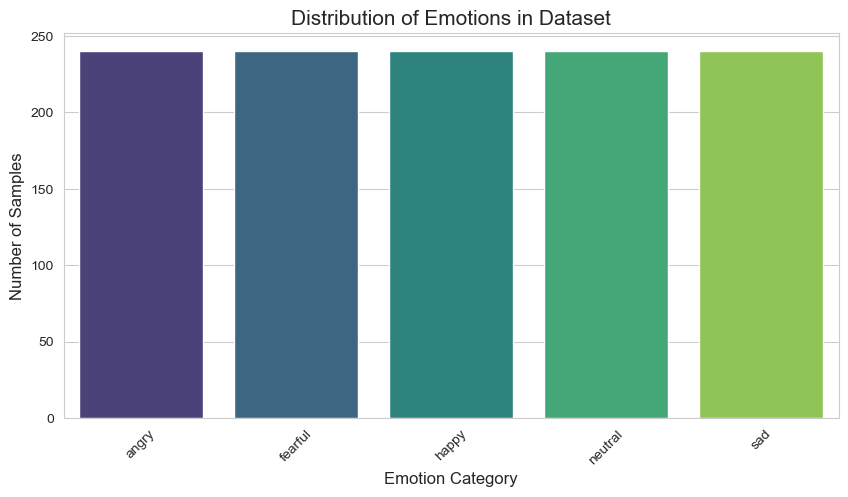

In [9]:
# JL Corpus specific mapping
JL_MAP = {
    'angry': 'angry',
    'anxious': 'fearful',
    'apologetic': 'apologetic',
    'assertive': 'assertive',
    'concerned': 'concerned',
    'encouraging': 'encouraging',
    'excited': 'excited',
    'happy': 'happy',
    'neutral': 'neutral',
    'sad': 'sad'
}

def load_jl_corpus_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} JL Corpus files...")

    for file in file_list:
        fname = os.path.basename(file)
        # female1_angry_2a_1.wav -> parts[1] is 'angry'
        parts = fname.split('_')
        
        if len(parts) > 1:
            code = parts[1].lower()
            emotion = JL_MAP.get(code)
            if emotion in ['apologetic', 'assertive', 'concerned', 'encouraging', 'excited']: # skipping the feature with least counts
                continue
            if emotion:
                X.append(extract_hybrid_features(file))
                y.append(emotion)
            
    return np.array(X), np.array(y)

JL_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\JL Corpus\Raw JL corpus (unchecked and unannotated)\JL(wav+txt)"
X_jl, y_jl = load_jl_corpus_data(JL_PATH)


# 10 emotions : angry, anxious, apologetic, assertive, concerned, encouraging, excited, happy, neutral, sad

makeThePlot(y_jl)

Extracting hybrid features from 1440 RAVDESS files...


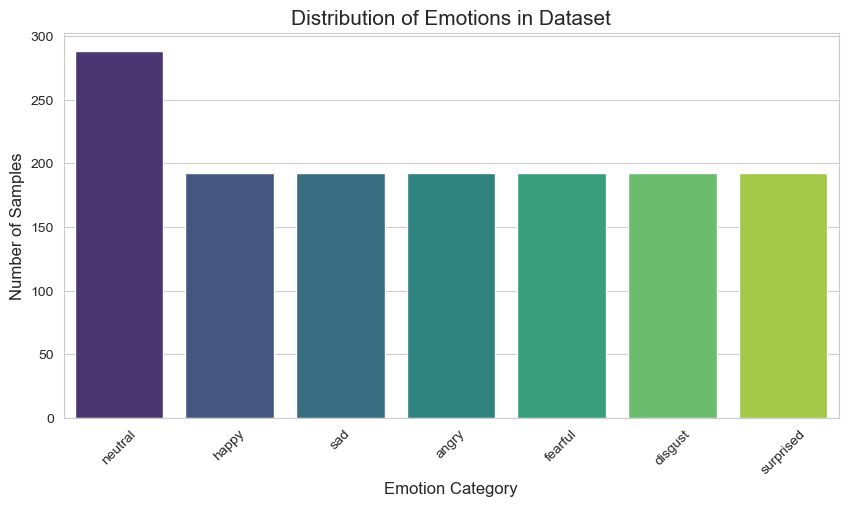

In [10]:
# Full RAVDESS emotion mapping
RAVDESS_MAP = {'01':'neutral', '02':'neutral', '03':'happy', '04':'sad', 
               '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'}

def load_ravdess_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "Actor_*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} RAVDESS files...")

    for file in file_list:
        emotion = RAVDESS_MAP[os.path.basename(file).split('-')[2]]
        X.append(extract_hybrid_features(file))
        y.append(emotion)
            
    return np.array(X), np.array(y)
    
RAVDESS_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\RAVDESS"
X_ravdess, y_ravdess = load_ravdess_data(RAVDESS_PATH)


# 8 emotions : neutral, calm, happy, sad, angry, fearful, disgust, surprised

makeThePlot(y_ravdess)

Extracting hybrid features from 480 SAVEE files...


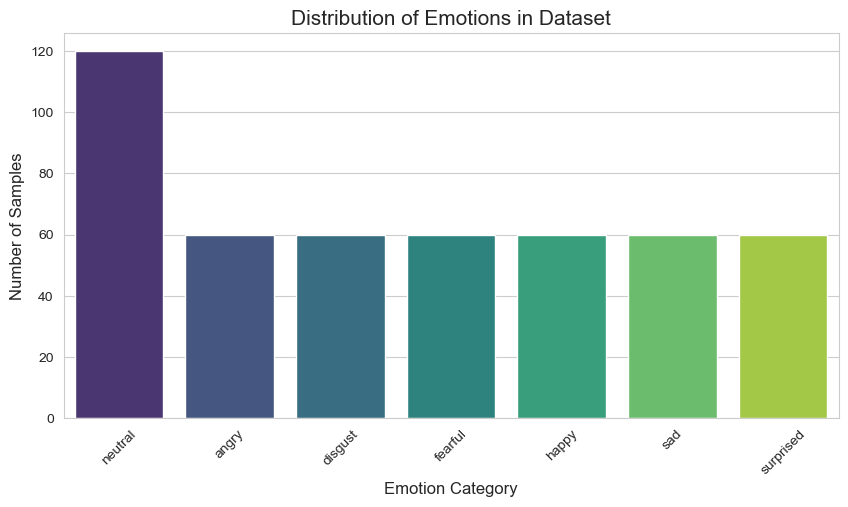

In [11]:
# SAVEE emotion mapping
SAVEE_MAP = {
    'a': 'angry', 
    'd': 'disgust', 
    'f': 'fearful', 
    'h': 'happy', 
    'n': 'neutral', 
    'sa': 'sad', 
    'su': 'surprised'
}

def load_savee_data(data_path):
    X, y = [], []
    file_list = os.listdir(data_path)
    print(f"Extracting hybrid features from {len(file_list)} SAVEE files...")

    for audio_file in file_list:
        try:
            part = audio_file.split('_')[1]
            code = part[:-6] 
            emotion = SAVEE_MAP.get(code)
            
            if emotion:
                full_path = os.path.join(data_path, audio_file)
                features = extract_hybrid_features(full_path)
                if features is not None:
                    X.append(features)
                    y.append(emotion)
                    
        except Exception as e:
            continue
            
    return np.array(X), np.array(y)


SAVEE_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\SAVEE\ALL"
X_savee, y_savee = load_savee_data(SAVEE_PATH)


# 7 emotions : angry, fearful, disgust, sad, happy, surprised, neutral

makeThePlot(y_savee)

Extracting hybrid features from 2800 TESS files...


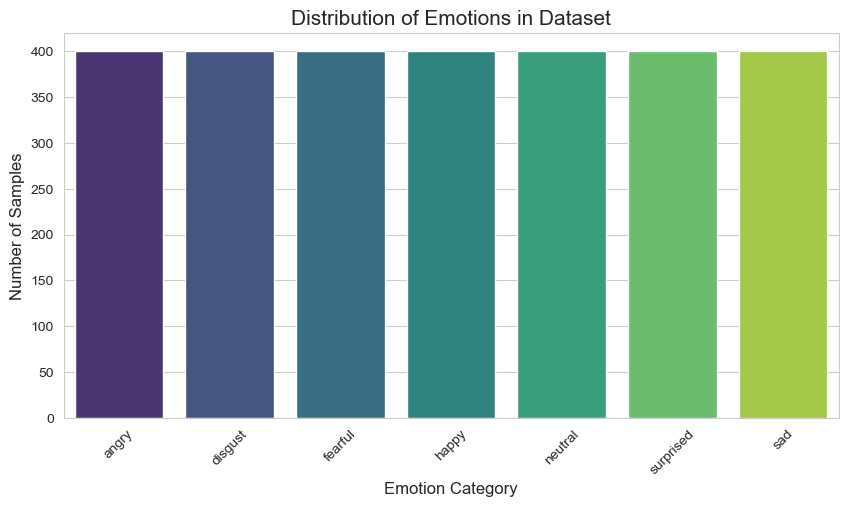

In [12]:
def load_tess_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} TESS files...")

    for file in file_list:
        # Get filename (e.g., 'OAF_back_angry.wav')
        fname = os.path.basename(file)
        emotion = fname.split('_')[-1].split('.')[0].lower()
        if emotion == 'ps':
            emotion = 'surprised'
        if emotion == 'fear':
            emotion = 'fearful'
        X.append(extract_hybrid_features(file))
        y.append(emotion)
            
    return np.array(X), np.array(y)

TESS_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\TESS\TESS Toronto emotional speech set data"
X_tess, y_tess = load_tess_data(TESS_PATH)


# 7 emotions : angry, fearful, disgust, sad, happy, surprised, neutral

makeThePlot(y_tess)

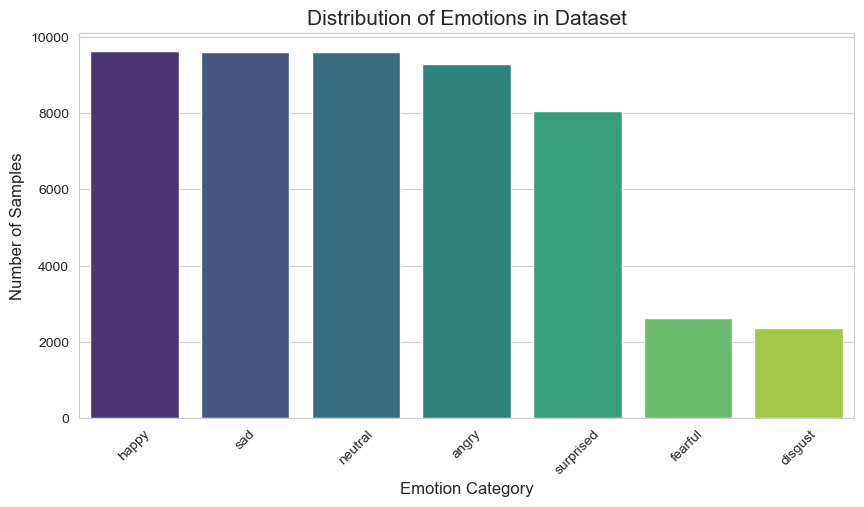

In [13]:
# After balancing the datasets, and dropping the unnecessary emotions. 
# Also not considering the MLEnd dataset (Numerals utterations)

Y_all = np.concatenate([y_ravdess, y_tess, y_savee, y_cremad, y_emodb, y_esd, y_hindi, y_jl], axis=0)
makeThePlot(Y_all)

In [14]:
datasets = {
    "RAVDESS": X_ravdess, "TESS": X_tess, "SAVEE": X_savee, 
    "CREMA-D": X_cremad, "EMO-DB": X_emodb, "ESD": X_esd, 
    "HINDI": X_hindi, "JL": X_jl
}

for name, data in datasets.items():
    print(f"{name} shape: {data.shape}")


RAVDESS shape: (1440, 128, 77)
TESS shape: (2800, 128, 77)
SAVEE shape: (480, 128, 77)
CREMA-D shape: (7442, 128, 77)
EMO-DB shape: (454, 128, 77)
ESD shape: (35000, 128, 77)
HINDI shape: (2400, 128, 77)
JL shape: (1200, 128, 77)


In [15]:
# Use saved features
USE_SAVED_FEATURES = False  # Toggle this

if USE_SAVED_FEATURES:
    print("Loading saved features...")
    X_all = np.load("features/X_all.npy")
    y_all = np.load("features/y_all.npy")

else:
    print("Using Extracted features from datasets...")

    # Combine all X and y arrays
    X_all = np.concatenate([X_ravdess, X_tess, X_savee, X_cremad, X_emodb, X_esd, X_hindi, X_jl], axis=0)
    y_all = np.concatenate([y_ravdess, y_tess, y_savee, y_cremad, y_emodb, y_esd, y_hindi, y_jl], axis=0)

    # Save features
    np.save("features/X_all.npy", X_all)
    np.save("features/y_all.npy", y_all)

    print("Features saved!")


# Scaling: We flatten to scale, then reshape back to (N, 128, 77)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all.reshape(-1, X_all.shape[-1])).reshape(X_all.shape)

# Convert text to Integers (e.g., 'neutral' -> 0, 'happy' -> 1)
lb = LabelEncoder()
y_integers = lb.fit_transform(y_all) 

# Convert those Integers to One-Hot Matrix (for the Model)
y_final = to_categorical(y_integers)

# Calculate Class Weights using the Integers
# It needs the simple list (y_integers) to count the frequencies
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)

dict_weights = dict(enumerate(weights))


Using Extracted features from datasets...
Features saved!


# Train-Test Split

In [16]:
# Use saved train-test splits
USE_SAVED_SPLITS = False  # Toggle this

if USE_SAVED_SPLITS and os.path.exists("splits/train_idx.npy"):
    print("Loading saved splits...")

    train_idx = np.load("splits/train_idx.npy")
    test_idx = np.load("splits/test_idx.npy")

    X_train = X_scaled[train_idx]
    X_test = X_scaled[test_idx]

    y_train = y_final[train_idx]
    y_test = y_final[test_idx]

    print("Loaded existing split")

else:
    print("Creating new split...")

    indices = np.arange(len(X_scaled))

    train_idx, test_idx = train_test_split(
        indices,
        test_size=0.2,
        random_state=42,
        stratify=y_integers
    )

    np.save("splits/train_idx.npy", train_idx)
    np.save("splits/test_idx.npy", test_idx)

    X_train = X_scaled[train_idx]
    X_test = X_scaled[test_idx]

    y_train = y_final[train_idx]
    y_test = y_final[test_idx]

    print("Split indices saved")

print(f"Data loaded: X_train shape {X_train.shape}, y_train shape {y_train.shape}")

Creating new split...
Split indices saved
Data loaded: X_train shape (40972, 128, 77), y_train shape (40972, 7)


# Create the Hybrid BiLSTM Model

In [17]:
model = Sequential([
    # Stage 1: Convolutional layers for local spectral patterns
    Conv1D(256, 5, padding='same', activation='relu', input_shape=(128, 77)),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    # Stage 2: Recurrent layers for temporal emotional rhythm
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    
    Bidirectional(LSTM(64)),
    Dropout(0.3),

    # Stage 3: Classification head
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(7, activation='softmax')
])

# Training Configuration
opt = Adam(learning_rate=0.0005)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# Callbacks to maximize accuracy and prevent overfitting
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    "models/best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [18]:
# Training the Model
print("Starting training...")
history = model.fit(X_train, y_train, 
                    epochs=200, 
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    callbacks=[reduce_lr, early_stop, checkpoint],
                    class_weight=dict_weights
                   )


Starting training...
Epoch 1/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.3650 - loss: 1.7654
Epoch 1: val_accuracy improved from None to 0.60679, saving model to models/best_model.h5



Epoch 1: finished saving model to models/best_model.h5
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 231s 166ms/step - accuracy: 0.4628 - loss: 1.4354 - val_accuracy: 0.6068 - val_loss: 1.0127 - learning_rate: 5.0000e-04
Epoch 2/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.6314 - loss: 0.9687
Epoch 2: val_accuracy improved from 0.60679 to 0.70568, saving model to models/best_model.h5



Epoch 2: finished saving model to models/best_model.h5
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 158s 124ms/step - accuracy: 0.6510 - loss: 0.9225 - val_accuracy: 0.7057 - val_loss: 0.7659 - learning_rate: 5.0000e-04
Epoch 3/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.7150 - loss: 0.7768
Epoch 3: val_accuracy improved from 0.70568 to 0.75078, saving model to models/best_model.h5



Epoch 3: finished saving model to models/best_model.h5
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 195s 118ms/step - accuracy: 0.7228 - loss: 0.7584 - val_accuracy: 0.7508 - val_loss: 0.6546 - learning_rate: 5.0000e-04
Epoch 4/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7622 - loss: 0.6557
Epoch 4: val_accuracy improved from 0.75078 to 0.77938, saving model to models/best_model.h5



Epoch 4: finished saving model to models/best_model.h5
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 195s 112ms/step - accuracy: 0.7637 - loss: 0.6560 - val_accuracy: 0.7794 - val_loss: 0.6105 - learning_rate: 5.0000e-04
Epoch 5/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7922 - loss: 0.5726
Epoch 5: val_accuracy improved from 0.77938 to 0.81335, saving model to models/best_model.h5


...


Epoch 45: finished saving model to models/best_model.h5
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 140s 107ms/step - accuracy: 0.9893 - loss: 0.0289 - val_accuracy: 0.8873 - val_loss: 0.5880 - learning_rate: 4.0000e-06
Epoch 46/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9906 - loss: 0.0269
Epoch 46: val_accuracy did not improve from 0.88735
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 139s 108ms/step - accuracy: 0.9906 - loss: 0.0259 - val_accuracy: 0.8872 - val_loss: 0.5878 - learning_rate: 4.0000e-06
Epoch 47/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9892 - loss: 0.0280
Epoch 47: val_accuracy did not improve from 0.88735
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 138s 108ms/step - accuracy: 0.9901 - loss: 0.0268 - val_accuracy: 0.8872 - val_loss: 0.5893 - learning_rate: 4.0000e-06
Epoch 48/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9902 - loss: 0.0283
Epoch 48: val_accuracy improved from 0.88735 to 0.88745, saving model to models/best_model.h5



Epoch 48: finished saving model to models/best_model.h5
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 147s 112ms/step - accuracy: 0.9907 - loss: 0.0272 - val_accuracy: 0.8874 - val_loss: 0.5899 - learning_rate: 4.0000e-06
Epoch 49/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9902 - loss: 0.0254
Epoch 49: val_accuracy did not improve from 0.88745
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 144s 112ms/step - accuracy: 0.9900 - loss: 0.0258 - val_accuracy: 0.8866 - val_loss: 0.5907 - learning_rate: 4.0000e-06
Epoch 50/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9904 - loss: 0.0264
Epoch 50: val_accuracy did not improve from 0.88745
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 195s 107ms/step - accuracy: 0.9908 - loss: 0.0255 - val_accuracy: 0.8862 - val_loss: 0.5902 - learning_rate: 4.0000e-06
Epoch 51/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9909 - loss: 0.0277
Epoch 51: val_accuracy did not improve from 0.88745
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 137s 107ms/step - accuracy: 0.


Epoch 67: finished saving model to models/best_model.h5
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 140s 110ms/step - accuracy: 0.9903 - loss: 0.0262 - val_accuracy: 0.8877 - val_loss: 0.5967 - learning_rate: 1.0000e-06
Epoch 68/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9910 - loss: 0.0262
Epoch 68: val_accuracy improved from 0.88774 to 0.88813, saving model to models/best_model.h5



Epoch 68: finished saving model to models/best_model.h5
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 142s 109ms/step - accuracy: 0.9915 - loss: 0.0259 - val_accuracy: 0.8881 - val_loss: 0.5951 - learning_rate: 1.0000e-06
Epoch 69/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9905 - loss: 0.0255
Epoch 69: val_accuracy did not improve from 0.88813
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 140s 109ms/step - accuracy: 0.9906 - loss: 0.0251 - val_accuracy: 0.8873 - val_loss: 0.5938 - learning_rate: 1.0000e-06
Epoch 70/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9902 - loss: 0.0274
Epoch 70: val_accuracy improved from 0.88813 to 0.88823, saving model to models/best_model.h5



Epoch 70: finished saving model to models/best_model.h5
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 143s 110ms/step - accuracy: 0.9906 - loss: 0.0261 - val_accuracy: 0.8882 - val_loss: 0.5938 - learning_rate: 1.0000e-06
Epoch 71/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9904 - loss: 0.0265
Epoch 71: val_accuracy did not improve from 0.88823
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 147s 114ms/step - accuracy: 0.9907 - loss: 0.0259 - val_accuracy: 0.8876 - val_loss: 0.5940 - learning_rate: 1.0000e-06
Epoch 72/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9908 - loss: 0.0262
Epoch 72: val_accuracy did not improve from 0.88823
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 198s 111ms/step - accuracy: 0.9903 - loss: 0.0275 - val_accuracy: 0.8876 - val_loss: 0.5947 - learning_rate: 1.0000e-06
Epoch 73/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9905 - loss: 0.0266
Epoch 73: val_accuracy did not improve from 0.88823
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 141s 110ms/step - accuracy: 0.

In [19]:
# Evaluating the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

# Save trained model
model.save("models/model.h5")

# Save scaler
joblib.dump(scaler, "models/scaler.pkl")

# Save label encoder
joblib.dump(lb, "models/label_encoder.pkl")

print("Model and preprocessing objects saved successfully!")

# Save Training History
with open("models/history.json", "w") as f:
    json.dump(history.history, f)

print("Training history saved!")

np.save("models/classes.npy", lb.classes_)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

print(f"Best Train Accuracy: {max(history.history['accuracy']) * 100:.2f}%")

321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.8882 - loss: 0.5938


Model and preprocessing objects saved successfully!
Training history saved!
Test Accuracy: 88.82%
Test Loss: 0.5938
Best Train Accuracy: 99.21%


# Plot the Results

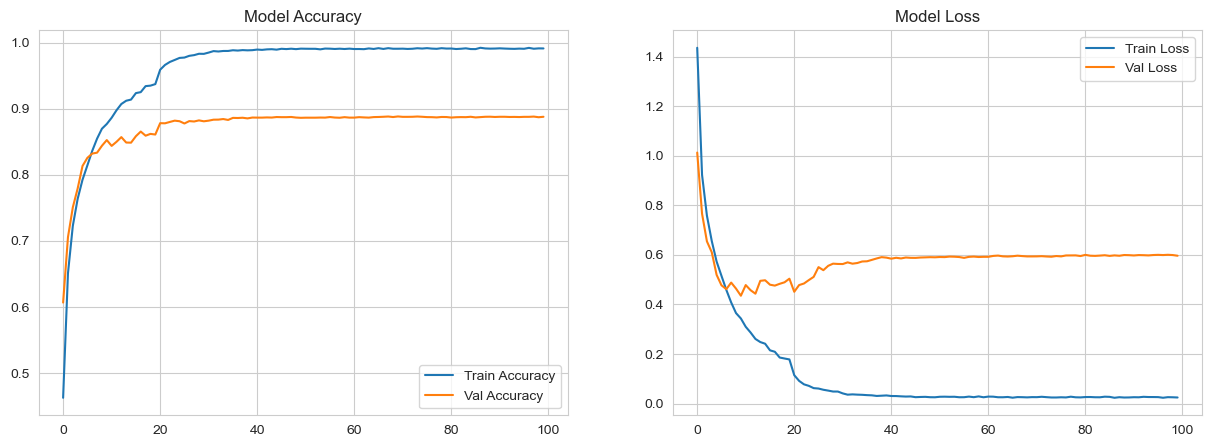

321/321 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step


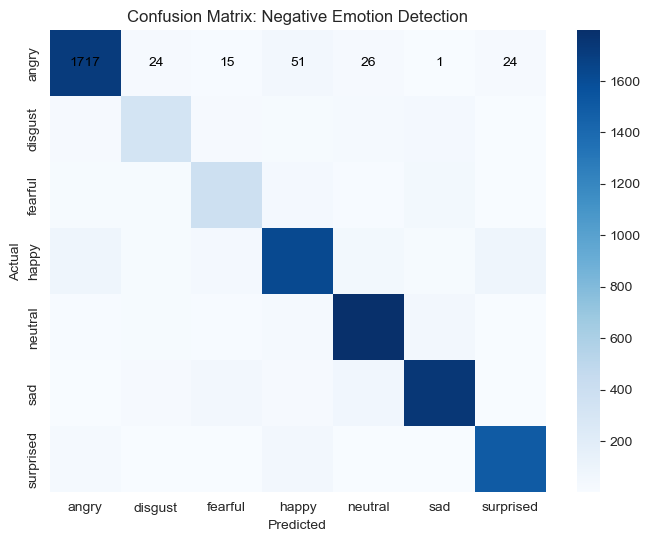


Classification Report:

              precision    recall  f1-score   support

       angry       0.90      0.92      0.91      1858
     disgust       0.75      0.70      0.72       474
     fearful       0.71      0.73      0.72       526
       happy       0.88      0.84      0.86      1927
     neutral       0.90      0.93      0.92      1923
         sad       0.92      0.91      0.91      1925
   surprised       0.93      0.93      0.93      1611

    accuracy                           0.89     10244
   macro avg       0.86      0.85      0.85     10244
weighted avg       0.89      0.89      0.89     10244



In [20]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Model Loss')
ax[1].legend()
plt.show()

# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
cm = cm.astype('int') 
sns.heatmap(np.array(cm), annot=True, fmt='d',annot_kws={"color": "black"}, xticklabels=lb.classes_, yticklabels=lb.classes_, cmap='Blues')
plt.title('Confusion Matrix: Negative Emotion Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=lb.classes_))


In [21]:
print(cm)

[[1717   24   15   51   26    1   24]
 [  27  330   28   17   32   39    1]
 [  22   18  386   38   11   47    4]
 [  89   20   37 1627   49   19   86]
 [  12   19   11   32 1797   51    1]
 [   2   23   56   28   67 1746    3]
 [  36    5    8   57    6    3 1496]]
